In [5]:
import os
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
from tqdm import tqdm

In [6]:
# -------------------------------
# Custom Dataset that uses your folder names
# -------------------------------
class DeepfakeDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        """
        root_dir: path to the main folder containing 'Real_Image' and 'fake_image'
        """
        self.samples = []
        self.transform = transform
        
        # Map folder names to labels: Real_Image -> 0 (real), fake_image -> 1 (fake)
        folders = {
            'Real_Image': 0,   # real
            'fake_image': 1    # fake
        }
        
        for folder_name, label in folders.items():
            class_dir = os.path.join(root_dir, folder_name)
            if not os.path.isdir(class_dir):
                raise FileNotFoundError(f"Folder not found: {class_dir}")
            for fname in os.listdir(class_dir):
                if fname.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                    self.samples.append((os.path.join(class_dir, fname), label))
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label


In [14]:
# %%
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in tqdm(dataloader, desc="Training"):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def validate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Validating"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc, all_preds, all_labels

c:\Users\aadrs\OneDrive\Desktop\Third EYE Project\Third EYE Project\venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\aadrs\OneDrive\Desktop\Third EYE Project\Third EYE Project\venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Using device: cpu
Total images found: 37
Training samples: 30, Validation samples: 7

Epoch 1/20


Validating: 100%|██████████| 1/1 [00:00<00:00,  2.36it/s]


Train Loss: 0.6564 | Train Acc: 0.5667
Val Loss: 0.6506 | Val Acc: 0.5714
Best model saved (acc=0.5714)

Epoch 2/20


Validating: 100%|██████████| 1/1 [00:00<00:00,  2.44it/s]


...

Train Loss: 0.0372 | Train Acc: 1.0000
Val Loss: 0.0512 | Val Acc: 1.0000

Epoch 20/20


Validating: 100%|██████████| 1/1 [00:00<00:00,  2.35it/s]


Train Loss: 0.0070 | Train Acc: 1.0000
Val Loss: 0.0555 | Val Acc: 1.0000


Validating: 100%|██████████| 1/1 [00:00<00:00,  2.18it/s]



===== Final Classification Report =====
              precision    recall  f1-score   support

        real       1.00      1.00      1.00         4
        fake       1.00      1.00      1.00         3

    accuracy                           1.00         7
   macro avg       1.00      1.00      1.00         7
weighted avg       1.00      1.00      1.00         7

Confusion Matrix:
[[4 0]
 [0 3]]
Confusion matrix saved as 'confusion_matrix.png'


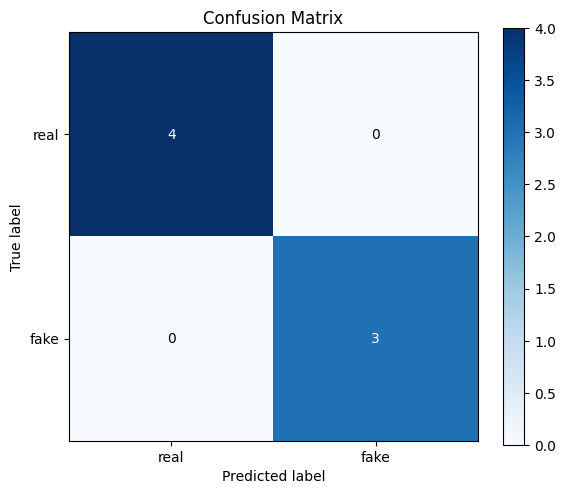

In [8]:
# %%
# -------------------------------
# Configuration (adjust these as needed)
# -------------------------------
DATA_DIR = "./Imagedataset"      # <-- CHANGE if your folder is elsewhere
EPOCHS = 20
BATCH_SIZE = 8
LEARNING_RATE = 0.0001
VAL_SPLIT = 0.2
SAVE_MODEL_PATH = "deepfake_model.pth"

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Transforms (with augmentation for training)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load full dataset
full_dataset = DeepfakeDataset(DATA_DIR, transform=train_transform)
print(f"Total images found: {len(full_dataset)}")

# Split into train and validation
val_size = int(VAL_SPLIT * len(full_dataset))
train_size = len(full_dataset) - val_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# For validation we use the non-augmented transform
val_dataset.dataset.transform = val_transform

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Training samples: {len(train_dataset)}, Validation samples: {len(val_dataset)}")

# Load pre-trained MobileNetV2
model = models.mobilenet_v2(pretrained=True)

# Freeze early layers (to avoid overfitting on small dataset)
for param in model.features.parameters():
    param.requires_grad = False
# Unfreeze the last 3 layers for fine-tuning
for param in model.features[-3:].parameters():
    param.requires_grad = True

# Replace classifier
num_classes = 2
model.classifier = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(model.last_channel, 128),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(128, num_classes)
)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Training loop
best_val_acc = 0.0
for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _ = validate(model, val_loader, criterion, device)
    
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), SAVE_MODEL_PATH)
        print(f"Best model saved (acc={val_acc:.4f})")

# Load best model and final evaluation
model.load_state_dict(torch.load(SAVE_MODEL_PATH))
_, _, final_preds, final_labels = validate(model, val_loader, criterion, device)

print("\n===== Final Classification Report =====")
print(classification_report(final_labels, final_preds, target_names=['real', 'fake']))

# Confusion matrix
cm = confusion_matrix(final_labels, final_preds)
print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['real', 'fake'])
plt.yticks(tick_marks, ['real', 'fake'])
plt.ylabel('True label')
plt.xlabel('Predicted label')
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', color='white' if cm[i, j] > cm.max()/2 else 'black')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
print("Confusion matrix saved as 'confusion_matrix.png'")

In [15]:
# %%
def predict_image(image_path, model, device):
    model.eval()
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    img = Image.open(image_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        outputs = model(img_tensor)
        probs = torch.softmax(outputs, dim=1)
        pred = torch.argmax(probs, dim=1).item()
    # label 0 = real, 1 = fake
    return ('real' if pred == 0 else 'fake'), probs[0].cpu().numpy()

# Example usage (uncomment and change path to test)
# test_image_path = "Imagedataset/Real_Image/your_image.jpg"
# pred_class, probs = predict_image(test_image_path, model, device)
# print(f"Prediction: {pred_class} (real prob: {probs[0]:.3f}, fake prob: {probs[1]:.3f})")

In [16]:
# %%
# Test on all images from the validation set (optional)
correct = 0
total = 0
for i, (img, label) in enumerate(val_dataset):
    img_path = val_dataset.dataset.samples[val_dataset.indices[i]][0]
    pred_class, _ = predict_image(img_path, model, device)
    true_class = 'real' if label == 0 else 'fake'
    if pred_class == true_class:
        correct += 1
    total += 1
print(f"Validation accuracy from prediction function: {correct/total:.2%}")

Validation accuracy from prediction function: 100.00%


In [17]:
# %%
# Test on all images from the validation set (optional)
correct = 0
total = 0
for i, (img, label) in enumerate(val_dataset):
    img_path = val_dataset.dataset.samples[val_dataset.indices[i]][0]
    pred_class, _ = predict_image(img_path, model, device)
    true_class = 'real' if label == 0 else 'fake'
    if pred_class == true_class:
        correct += 1
    total += 1
print(f"Validation accuracy from prediction function: {correct/total:.2%}")

Validation accuracy from prediction function: 100.00%


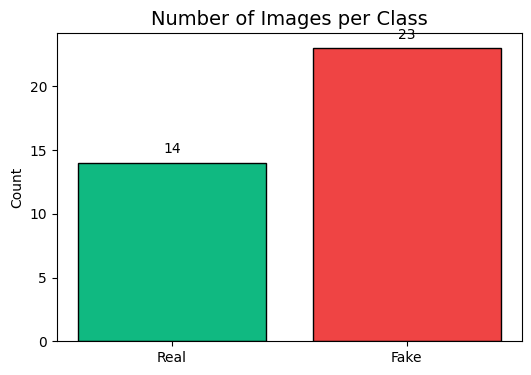

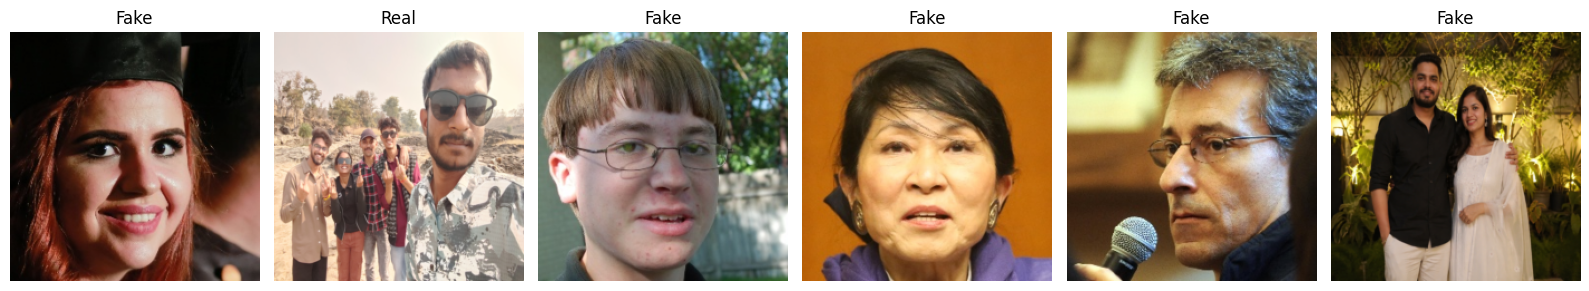

In [18]:
# %% [markdown]
# ## 📊 Dataset Visualization

# %%
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# Count images per class
class_counts = Counter()
for _, label in full_dataset.samples:
    class_counts[label] += 1

labels = ['Real', 'Fake']
counts = [class_counts[0], class_counts[1]]

plt.figure(figsize=(6,4))
bars = plt.bar(labels, counts, color=['#10b981', '#ef4444'], edgecolor='black')
plt.title('Number of Images per Class', fontsize=14)
plt.ylabel('Count')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5, f'{int(height)}', ha='center', va='bottom')
plt.show()

# Display a grid of sample images
def show_sample_grid(dataset, num_samples=8):
    fig, axes = plt.subplots(1, num_samples, figsize=(16, 4))
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    for i, idx in enumerate(indices):
        img, label = dataset[idx]
        # Unnormalize for display
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = img.numpy().transpose((1,2,0)) * std + mean
        img = np.clip(img, 0, 1)
        axes[i].imshow(img)
        axes[i].set_title('Real' if label==0 else 'Fake')
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

show_sample_grid(full_dataset, num_samples=6)

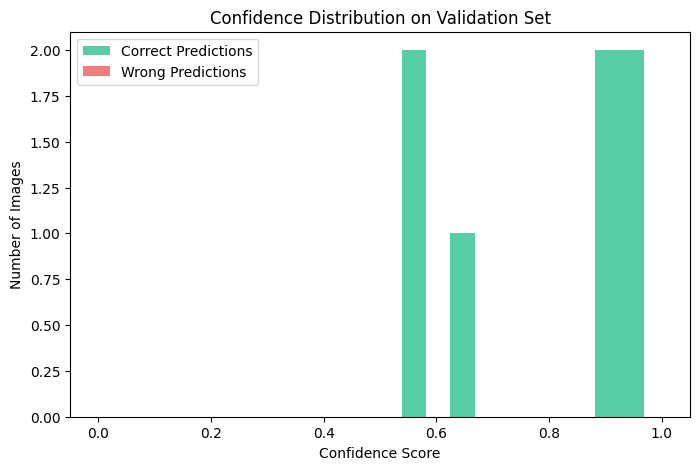

In [19]:
# %% [markdown]
# ## 📈 Prediction Confidence on Validation Set

# %%
# Collect confidence scores
confidences = []
true_labels = []
pred_labels = []

with torch.no_grad():
    for img, label in val_loader:
        img = img.to(device)
        outputs = model(img)
        probs = torch.softmax(outputs, dim=1)
        conf, pred = torch.max(probs, dim=1)
        confidences.extend(conf.cpu().numpy())
        true_labels.extend(label.numpy())
        pred_labels.extend(pred.cpu().numpy())

# Separate correct and incorrect predictions
correct_confs = [confidences[i] for i in range(len(confidences)) if true_labels[i] == pred_labels[i]]
wrong_confs = [confidences[i] for i in range(len(confidences)) if true_labels[i] != pred_labels[i]]

plt.figure(figsize=(8,5))
plt.hist(correct_confs, bins=10, alpha=0.7, label='Correct Predictions', color='#10b981')
plt.hist(wrong_confs, bins=10, alpha=0.7, label='Wrong Predictions', color='#ef4444')
plt.xlabel('Confidence Score')
plt.ylabel('Number of Images')
plt.title('Confidence Distribution on Validation Set')
plt.legend()
plt.savefig('confidence_distribution.png')
plt.show()